# Abalone Regression Experiment

## kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation

This notebook presents a complete and reproducible regression experiment using the Abalone dataset.

The experiment evaluates three groups of models:

1. Baseline machine learning regressors
2. COBRA-based regression aggregation models
3. KFCProcedure regression models

The notebook is designed for direct use as experimental evidence for Chapter 7: Experiments and Results of the master's thesis. The workflow emphasizes reproducibility, fair model comparison, statistical reporting, and consistency with the repository experiment notebook.

## 1. Objective

### Purpose

The purpose of this experiment is to evaluate the predictive performance of baseline regression models, COBRA-based regression aggregation, and KFCProcedure-based regression on the Abalone dataset.

The Abalone task is formulated as a regression problem where the goal is to predict the number of rings from physical measurements and sex category information.

### Research Questions

This experiment addresses the following research questions:

1. How do standard machine learning regressors perform on the Abalone regression task?
2. How do repository-supported COBRA regression models compare with baseline regressors?
3. How do KFCProcedure regression models compare with baseline and COBRA models?
4. Are the observed results stable across multiple random train-test splits?

### Expected Evaluation

Because this is a regression task, the experiment uses repeated evaluation and reports:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination ($R^2$)

The repository notebook also uses Mean Absolute Percentage Error (MAPE) and the average of the true target values as additional descriptive outputs. These are reported as supplementary metrics.

The repeated evaluation uses:

```python
SEEDS = [42, 52, 62, 72, 82]
```

## 2. Dataset Description

### 2.1 Dataset Overview

The dataset used in this experiment is the Abalone dataset loaded from Kaggle in the repository notebook.

Repository notebook source:

```text
rodolfomendes/abalone-dataset
```

Repository notebook file:

```text
abalone.csv
```

Each row represents one abalone sample. The dataset contains physical measurements and a sex category variable.

### 2.2 Feature Description

The observed feature columns are:

- `Sex`
- `Length`
- `Diameter`
- `Height`
- `Whole weight`
- `Shucked weight`
- `Viscera weight`
- `Shell weight`

The feature `Sex` is categorical. The remaining features are numerical.

### 2.3 Target Variable

The target variable is:

```text
Rings
```

The model predicts `Rings` as a continuous numeric outcome, following the repository's regression experiment formulation.

## 3. Import Libraries and Repository Modules

This section imports the scientific Python stack, scikit-learn models, and repository-supported KFC/COBRA models used in the experiment.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

### Repository Import Configuration

The experiment uses repository modules directly:

- `GradientCOBRA`
- `MixCOBRARegressor`
- `KFCRegressor`

`CombinedClassifier` is not used in this regression experiment because it is a classification model. For regression, the repository notebook uses `GradientCOBRA` and `MixCOBRARegressor`.

In [2]:
def find_repo_root(start_path=None):
    """
    Locate the repository root by searching upward for src/kfc_procedure.
    """
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)

    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "src" / "kfc_procedure").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate repository root containing src/kfc_procedure. "
        "Run this notebook inside the kfc-procedure repository or install the package."
    )

try:
    from kfc_procedure.cobra.gradientcobra import GradientCOBRA
    from kfc_procedure.cobra.mixcobra import MixCOBRARegressor
    from kfc_procedure.kfc import KFCRegressor
    from kfc_procedure.cobra.combined_classifier import CombinedClassifier
    print("Repository classes imported from installed environment.")
except ImportError:
    repo_root = find_repo_root()
    sys.path.insert(0, str(repo_root / "src"))

    from kfc_procedure.cobra.gradientcobra import GradientCOBRA
    from kfc_procedure.cobra.mixcobra import MixCOBRARegressor
    from kfc_procedure.kfc import KFCRegressor
    from kfc_procedure.cobra.combined_classifier import CombinedClassifier

    print(f"Repository classes imported from source path: {repo_root / 'src'}")

print("CombinedClassifier import status: available but not used for regression.")

Repository classes imported from installed environment.
CombinedClassifier import status: available but not used for regression.


## 4. Environment Configuration

The following cell records the software environment. This supports reproducibility and helps explain possible differences across executions.

In [3]:
environment_info = {
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    "NumPy": np.__version__,
    "Pandas": pd.__version__,
    "Scikit-learn": sklearn.__version__,
}

environment_table = pd.DataFrame(
    environment_info.items(),
    columns=["Component", "Version"],
)

environment_table

,Component,Version
0,Python,3.11.15
1,Platform,macOS-26.5.1-arm64-arm-64bit
2,NumPy,2.4.6
3,Pandas,3.0.3
4,Scikit-learn,1.9.0


## 5. Load Dataset

The dataset is loaded from Kaggle using `kagglehub`, following the repository notebook source.

If the dataset has already been downloaded, `kagglehub` reuses the local cached copy.

In [4]:
try:
    from kagglehub import dataset_download
except ImportError:
    %pip install kagglehub
    from kagglehub import dataset_download

path = dataset_download("rodolfomendes/abalone-dataset")
print("Dataset directory:", path)
print("Files:", os.listdir(path))

csv_path = os.path.join(path, "abalone.csv")
df_raw = pd.read_csv(csv_path)

df_raw.head()

Dataset directory: /Users/ougi/.cache/kagglehub/datasets/rodolfomendes/abalone-dataset/versions/3
Files: ['abalone.csv']


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 6. Exploratory Data Analysis (EDA)

This section follows the dataset and repository-supported EDA logic:

1. Dataset shape
2. Data types
3. Missing value analysis
4. Duplicate analysis
5. Target distribution
6. Feature statistics
7. Correlation analysis
8. Additional visualizations

The repository notebook also inspects the `Height` variable and filters invalid or extreme values using:

```python
df = df.query('Height > 0 and Height < 0.5')
```

### 6.1 Dataset Shape

The raw dataset shape reports the number of observations and variables before any cleaning.

In [5]:
print("Raw dataset shape:", df_raw.shape)
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

Raw dataset shape: (4177, 9)
Number of rows: 4177
Number of columns: 9


### 6.2 Data Types

The following table reports the raw data type of each column.

In [6]:
data_types_table = pd.DataFrame({
    "Feature": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
})

data_types_table

,Feature,Data Type
0,Sex,str
1,Length,float64
2,Diameter,float64
3,Height,float64
4,Whole weight,float64
5,Shucked weight,float64
6,Viscera weight,float64
7,Shell weight,float64
8,Rings,int64


### 6.3 Missing Value Analysis

Missing values are checked using:

```python
df.isnull().sum()
```

In [7]:
missing_values_table = (
    df_raw
    .isnull()
    .sum()
    .reset_index()
)
missing_values_table.columns = ["Feature", "Missing Values"]
missing_values_table["Missing Percentage"] = (
    missing_values_table["Missing Values"] / len(df_raw) * 100
)

missing_values_table

,Feature,Missing Values,Missing Percentage
0,Sex,0,0.0
1,Length,0,0.0
2,Diameter,0,0.0
3,Height,0,0.0
4,Whole weight,0,0.0
5,Shucked weight,0,0.0
6,Viscera weight,0,0.0
7,Shell weight,0,0.0
8,Rings,0,0.0


In [8]:
total_missing_values = int(df_raw.isnull().sum().sum())
print("Total missing values:", total_missing_values)

if total_missing_values == 0:
    print("No missing values were found in the loaded dataset.")
else:
    print("Missing values were found. Imputation is performed inside the preprocessing pipeline.")

Total missing values: 0
No missing values were found in the loaded dataset.


### 6.4 Duplicate Analysis

Duplicate rows are inspected using:

```python
df.duplicated().sum()
```

Duplicate removal is not explicitly observable in the repository Abalone notebook. Therefore, duplicate rows are reported but not removed unless explicitly justified later.

In [9]:
duplicate_count = int(df_raw.duplicated().sum())

print("Number of duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_count / len(df_raw) * 100, 4), "%")

Number of duplicate rows: 0
Duplicate percentage: 0.0 %


### 6.5 Target Distribution

The target variable `Rings` is continuous/integer-valued and is visualized using a histogram.

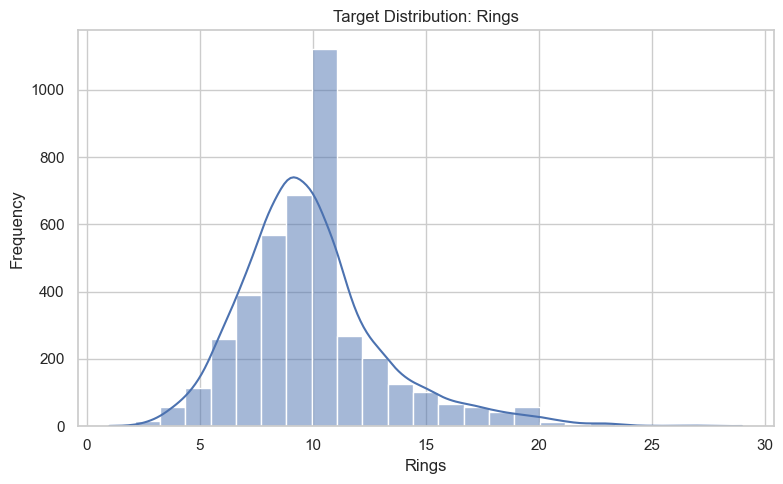

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df_raw["Rings"], bins=25, kde=True)
plt.title("Target Distribution: Rings")
plt.xlabel("Rings")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 6.6 Feature Statistics

The following table summarizes numerical feature distributions in the raw dataset.

In [11]:
feature_statistics_table = df_raw.describe().T
feature_statistics_table

,count,mean,std,min,25%,50%,75%,max
Length,4177.0,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150
Diameter,4177.0,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500
Height,4177.0,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300
Whole weight,4177.0,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255
Shucked weight,4177.0,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880
Viscera weight,4177.0,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600
Shell weight,4177.0,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050
Rings,4177.0,9.933684,3.224169,1.0000,8.0000,9.0000,11.000,29.0000


### 6.7 Correlation Analysis

Correlation analysis is computed for numeric variables only.

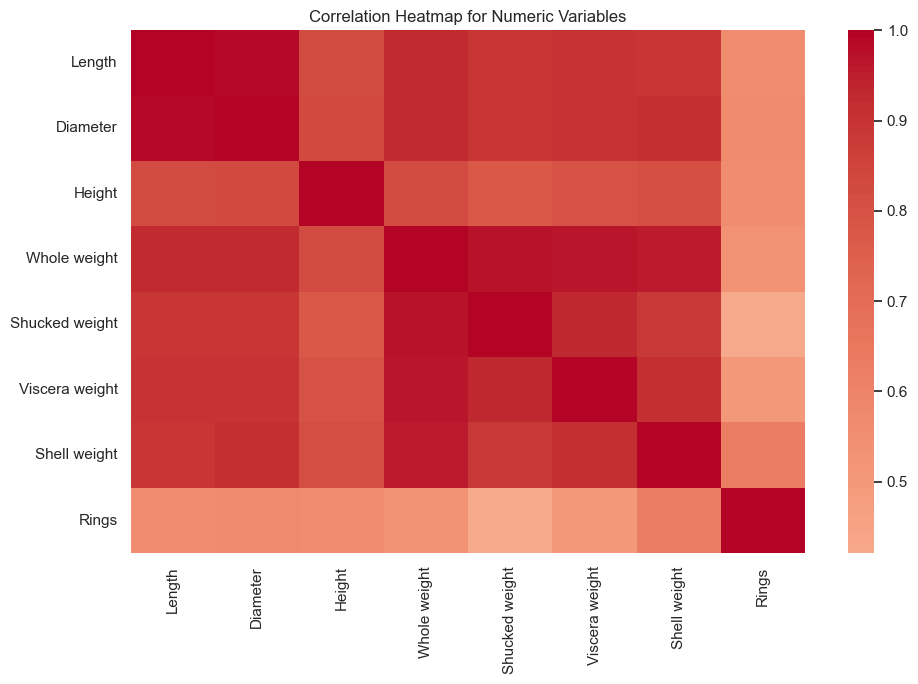

In [12]:
numeric_columns_raw = df_raw.select_dtypes(include=["int64", "float64"]).columns
correlation_matrix_raw = df_raw[numeric_columns_raw].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix_raw, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap for Numeric Variables")
plt.tight_layout()
plt.show()

### 6.8 Additional Visualizations

The following visualizations are exploratory and are not used as model-selection criteria.

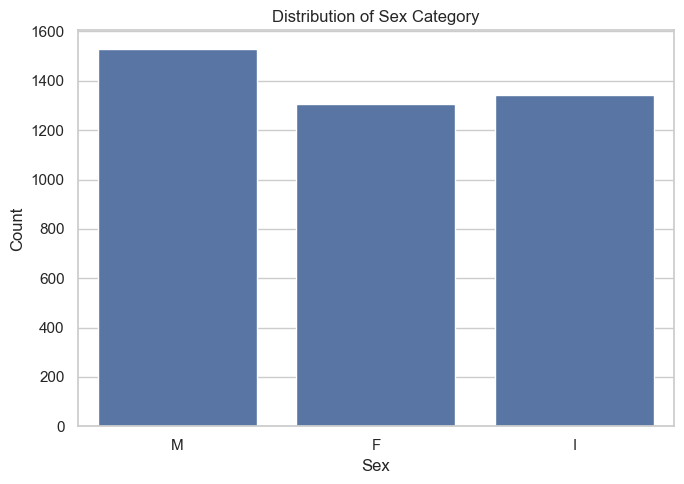

In [13]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df_raw, x="Sex")
plt.title("Distribution of Sex Category")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

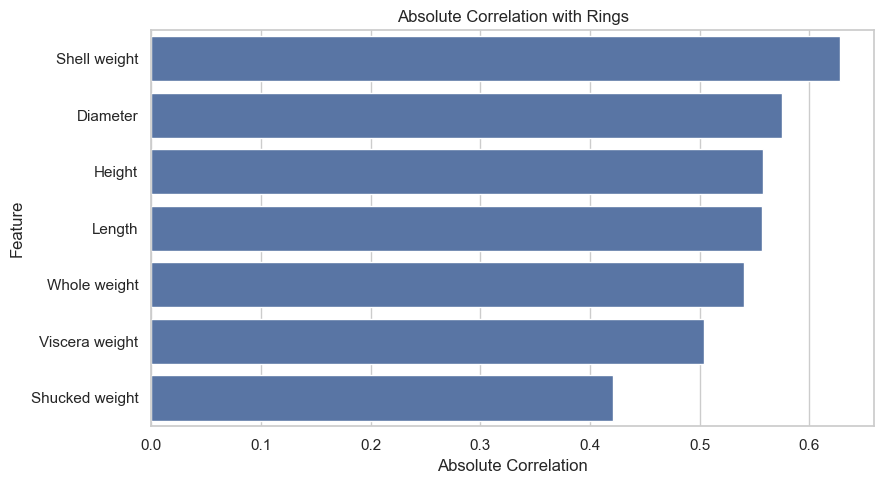

In [14]:
target_correlation = (
    correlation_matrix_raw["Rings"]
    .drop("Rings")
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=target_correlation.values, y=target_correlation.index)
plt.title("Absolute Correlation with Rings")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. Data Cleaning

### 7.1 Missing Value Handling

The repository notebook defines imputation inside the preprocessing pipeline:

- Numerical variables: `SimpleImputer(strategy="median")`
- Categorical variables: `SimpleImputer(strategy="most_frequent")`

### 7.2 Duplicate Removal

Duplicate removal is not explicitly observable from the provided Abalone notebook. Duplicate rows are reported in EDA, but no duplicate-removal step is applied in this notebook.

### 7.3 Outlier Inspection

The repository notebook specifically inspects and filters the `Height` variable using:

```python
df = df.query('Height > 0 and Height < 0.5')
```

No broader outlier detection rule is observable from the provided materials.

### 7.4 Data Consistency Checks

The following checks are performed:

- Confirm target column exists.
- Confirm feature columns are available.
- Confirm the filtered dataset is non-empty.

In [15]:
df = df_raw.copy()

if "Rings" not in df.columns:
    raise ValueError("Target column 'Rings' was not found in the dataset.")

height_zero_count = int((df["Height"] == 0).sum())
height_extreme_count = int((df["Height"] >= 0.5).sum())

print("Rows with Height == 0:", height_zero_count)
print("Rows with Height >= 0.5:", height_extreme_count)

rows_before_height_filter = len(df)
df = df.query("Height > 0 and Height < 0.5").copy()
rows_after_height_filter = len(df)

print("Rows before Height filter:", rows_before_height_filter)
print("Rows after Height filter:", rows_after_height_filter)
print("Rows removed by Height filter:", rows_before_height_filter - rows_after_height_filter)

if len(df) == 0:
    raise ValueError("The cleaned dataset is empty after Height filtering.")

Rows with Height == 0: 2
Rows with Height >= 0.5: 2
Rows before Height filter: 4177
Rows after Height filter: 4173
Rows removed by Height filter: 4


In [16]:
print("Cleaned dataset shape:", df.shape)
print("Remaining missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows after Height filtering:", int(df.duplicated().sum()))

df.head()

Cleaned dataset shape: (4173, 9)
Remaining missing values: 0
Duplicate rows after Height filtering: 0


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 8. Data Preprocessing

### 8.1 Feature Encoding

The categorical column `Sex` is encoded using one-hot encoding:

```python
OneHotEncoder(handle_unknown="ignore")
```

### 8.2 Feature Scaling

Numerical variables are imputed using the median and scaled using:

```python
MinMaxScaler(feature_range=(0.05, 0.95))
```

This scaling range follows the repository notebook and is useful for divergence-based methods requiring positive feature values.

### 8.3 Feature Selection

Feature selection is not observable from the provided materials. Therefore, all columns except `Rings` are used as input features.

### 8.4 Final Feature Matrix

The final feature matrix is:

```python
X = df.drop(columns=["Rings"])
```

The target vector is:

```python
y = df["Rings"]
```

In [17]:
target = "Rings"

X = df.drop(columns=[target])
y = df[target]

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Categorical columns: ['Sex']
Numerical columns: ['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']
Feature matrix shape: (4173, 8)
Target vector shape: (4173,)


In [18]:
def make_one_hot_encoder():
    """
    Create a dense OneHotEncoder compatible with different scikit-learn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler(feature_range=(0.05, 0.95))),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_one_hot_encoder()),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])


def to_dense_array(matrix):
    """
    Convert sparse or pandas/numpy matrix-like objects to a dense numpy array.
    """
    if hasattr(matrix, "toarray"):
        return matrix.toarray()
    return np.asarray(matrix)

## 9. Experimental Setup

### 9.1 Environment Configuration

The environment configuration was recorded earlier in this notebook.

### 9.2 Random Seed Configuration

The experiment uses repeated evaluation with:

```python
SEEDS = [42, 52, 62, 72, 82]
```

### 9.3 Train-Test Split Strategy

For each seed, the dataset is split using:

```python
train_test_split(X, y, test_size=0.2, random_state=seed)
```

No stratification is used because this is a regression task.

### 9.4 Hyperparameter Configuration

The baseline models follow the repository notebook model families:

- Linear Regression
- Ridge
- Lasso
- Random Forest Regressor
- Gradient Boosting Regressor
- SVR
- KNeighborsRegressor

The COBRA regression models are:

- `GradientCOBRA`
- `MixCOBRARegressor`

The KFCProcedure regression models are:

- `KFCRegressor` with `gradientcobra` combiner
- `KFCRegressor` with `mixcobra` combiner

### 9.5 Evaluation Protocol

For every seed:

1. Split the data.
2. Fit preprocessing only on the training data.
3. Transform train and test features.
4. Train all baseline models.
5. Train COBRA regression models.
6. Train KFCProcedure regression models.
7. Predict on the same test split.
8. Store all metric values in `all_results`.

In [19]:
SEEDS = [42, 52, 62, 72, 82]
TEST_SIZE = 0.2
PRIMARY_METRIC = "R2"

print("Seeds:", SEEDS)
print("Test size:", TEST_SIZE)
print("Primary ranking metric:", PRIMARY_METRIC)

Seeds: [42, 52, 62, 72, 82]
Test size: 0.2
Primary ranking metric: R2


## 10. Evaluation Metrics

Let $y_i$ be the true value, $\hat{y}_i$ be the predicted value, $n$ be the number of test observations, and $\bar{y}$ be the mean of the true values.

### Mean Absolute Error (MAE)

\[
MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
\]

Scikit-learn implementation:

```python
mean_absolute_error(y_true, y_pred)
```

### Mean Squared Error (MSE)

\[
MSE = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\]

Scikit-learn implementation:

```python
mean_squared_error(y_true, y_pred)
```

### Root Mean Squared Error (RMSE)

\[
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
\]

Scikit-learn implementation:

```python
root_mean_squared_error(y_true, y_pred)
```

### Coefficient of Determination ($R^2$)

\[
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
\]

Scikit-learn implementation:

```python
r2_score(y_true, y_pred)
```

### Supplementary Metric: MAPE

The repository notebook also reports MAPE:

```python
mean_absolute_percentage_error(y_true, y_pred)
```

In [20]:
def evaluate_regression(y_true, y_pred):
    """
    Evaluate regression predictions using thesis-required metrics and
    repository-observed supplementary metrics.
    """
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "AVG_Y_TRUE": float(np.mean(y_true)),
    }

## 11. Baseline Models

For each baseline model, the experiment performs:

1. Configuration
2. Training
3. Prediction
4. Evaluation

A standalone Decision Tree Regressor is not added because it is not observable as a separately evaluated baseline in the provided Abalone repository notebook.

In [21]:
def make_baseline_models(seed):
    """
    Create baseline models for one seed-specific run.
    """
    return {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(),
        "Lasso": Lasso(),
        "Random Forest Regressor": RandomForestRegressor(
            n_estimators=300,
            random_state=seed,
            n_jobs=-1,
        ),
        "Gradient Boosting Regressor": GradientBoostingRegressor(
            random_state=seed,
        ),
        "SVR": SVR(),
        "KNeighborsRegressor": KNeighborsRegressor(),
    }

## 12. COBRA Experiments

### Configuration

The repository-supported COBRA regression models used here are:

- `GradientCOBRA`
- `MixCOBRARegressor`

`CombinedClassifier` is not used because this experiment is a regression task and `CombinedClassifier` is classification-oriented.

### Training

The COBRA models are trained on the preprocessed training matrix.

### Prediction

Predictions are generated on the corresponding preprocessed test matrix.

### Evaluation

Predictions are evaluated using MAE, MSE, RMSE, $R^2$, and supplementary MAPE.

In [22]:
def make_gradientcobra(seed, estimator_names):
    return GradientCOBRA(
        estimators=list(estimator_names),
        random_state=seed,
    )


def make_mixcobra(seed, estimator_names):
    return MixCOBRARegressor(
        estimators=list(estimator_names),
        opt_method="grad",
        optimizer="gd",
        max_iter=100,
        learning_rate=1,
        random_state=seed,
    )

## 13. KFCProcedure Experiments

The KFCProcedure regression experiment uses `KFCRegressor`.

### Configuration

Two KFC configurations are evaluated:

1. `KFCRegressor` with `gradientcobra` combiner
2. `KFCRegressor` with `mixcobra` combiner

### K-Step

The K-Step applies divergence-based clustering using the repository-observed divergences:

- `euclidean`
- `gkl`
- `is`

### F-Step

The F-Step trains cluster-wise local models using:

- `linear_regression`

### C-Step

The C-Step aggregates intermediate predictions using one of the following regression combiners:

- `gradientcobra`
- `mixcobra`

### Training and Prediction

The preprocessed feature matrix is additionally scaled to the positive interval `(0.05, 0.95)` before fitting KFCProcedure models. This follows the repository notebook and supports positive-valued divergence computations.

In [23]:
def make_kfc_gradientcobra(seed):
    return KFCRegressor(
        divergences=["euclidean", "gkl", "is"],
        local_model="linear_regression",
        combiner="gradientcobra",
        combiner_params={"max_iter": 100, "random_state": seed},
        n_clusters=3,
        random_state=seed,
    )


def make_kfc_mixcobra(seed):
    return KFCRegressor(
        divergences=["euclidean", "gkl", "is"],
        local_model="linear_regression",
        combiner="mixcobra",
        combiner_params={"max_iter": 100, "random_state": seed, "opt_method": "grad", "optimizer": "gd"},
        n_clusters=3,
        random_state=seed,
    )

## 14. Repeated Evaluation Function

The following function executes one full seed-specific experiment. It produces one result dictionary per model.

In [24]:
def run_single_seed_experiment(seed, X, y):
    """
    Run one seed-specific regression experiment.
    """
    np.random.seed(seed)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=seed,
    )

    X_train_p = preprocessor.fit_transform(X_train)
    X_test_p = preprocessor.transform(X_test)

    X_train_p = to_dense_array(X_train_p)
    X_test_p = to_dense_array(X_test_p)

    seed_results = []

    baseline_models = make_baseline_models(seed)

    print("Running baseline models...")
    for model_name, model in baseline_models.items():
        start_fit = time.perf_counter()
        model.fit(X_train_p, y_train)
        fit_time = time.perf_counter() - start_fit

        start_predict = time.perf_counter()
        y_pred = model.predict(X_test_p)
        predict_time = time.perf_counter() - start_predict

        metrics = evaluate_regression(y_test, y_pred)

        seed_results.append({
            "Model": model_name,
            "Seed": seed,
            **metrics,
            "Fit Time": fit_time,
            "Prediction Time": predict_time,
        })

    estimator_names = [
        "linear_regression",
        "ridge",
        "lasso",
        "random_forest_regressor",
        "gradient_boosting_regressor",
        "svr",
        "k_neighbors_regressor",
    ]

    print("Running GradientCOBRA...")
    gradientcobra = make_gradientcobra(seed, estimator_names)

    start_fit = time.perf_counter()
    gradientcobra.fit(X_train_p, y_train)
    fit_time = time.perf_counter() - start_fit

    start_predict = time.perf_counter()
    y_pred = gradientcobra.predict(X_test_p)
    predict_time = time.perf_counter() - start_predict

    metrics = evaluate_regression(y_test, y_pred)

    seed_results.append({
        "Model": "GradientCOBRA",
        "Seed": seed,
        **metrics,
        "Fit Time": fit_time,
        "Prediction Time": predict_time,
    })

    print("Running MixCOBRARegressor...")
    mixcobra = make_mixcobra(seed, estimator_names)

    start_fit = time.perf_counter()
    mixcobra.fit(X_train_p, y_train)
    fit_time = time.perf_counter() - start_fit

    start_predict = time.perf_counter()
    y_pred = mixcobra.predict(X_test_p)
    predict_time = time.perf_counter() - start_predict

    metrics = evaluate_regression(y_test, y_pred)

    seed_results.append({
        "Model": "MixCOBRARegressor",
        "Seed": seed,
        **metrics,
        "Fit Time": fit_time,
        "Prediction Time": predict_time,
    })

    print("Running KFCRegressor with GradientCOBRA combiner...")
    kfc_scaler = MinMaxScaler(feature_range=(0.05, 0.95))
    X_train_kfc = kfc_scaler.fit_transform(X_train_p)
    X_test_kfc = kfc_scaler.transform(X_test_p)

    kfc_gradientcobra = make_kfc_gradientcobra(seed)

    start_fit = time.perf_counter()
    kfc_gradientcobra.fit(X_train_kfc, y_train)
    fit_time = time.perf_counter() - start_fit

    start_predict = time.perf_counter()
    y_pred = kfc_gradientcobra.predict(X_test_kfc)
    predict_time = time.perf_counter() - start_predict

    metrics = evaluate_regression(y_test, y_pred)

    seed_results.append({
        "Model": "KFCRegressor-GradientCOBRA",
        "Seed": seed,
        **metrics,
        "Fit Time": fit_time,
        "Prediction Time": predict_time,
    })

    # print("Running KFCRegressor with MixCOBRA combiner...")
    # kfc_mixcobra = make_kfc_mixcobra(seed)

    # start_fit = time.perf_counter()
    # kfc_mixcobra.fit(X_train_kfc, y_train)
    # fit_time = time.perf_counter() - start_fit

    # start_predict = time.perf_counter()
    # y_pred = kfc_mixcobra.predict(X_test_kfc)
    # predict_time = time.perf_counter() - start_predict

    # metrics = evaluate_regression(y_test, y_pred)

    # seed_results.append({
    #     "Model": "KFCRegressor-MixCOBRA",
    #     "Seed": seed,
    #     **metrics,
    #     "Fit Time": fit_time,
    #     "Prediction Time": predict_time,
    # })

    return seed_results

## 15. Execute Repeated Experiment

The experiment stores all results in:

```python
all_results = []
```

Each row stores:

- model
- seed
- MAE
- MSE
- RMSE
- R2
- MAPE
- average true target value
- fit time
- prediction time

In [25]:
def run_repeated_experiment(X, y, seeds):
    all_results = []

    for seed in seeds:
        print("=" * 80)
        print(f"Running experiment for seed = {seed}")
        print("=" * 80)
        seed_results = run_single_seed_experiment(seed, X, y)
        all_results.extend(seed_results)

    return all_results


if __name__ == "__main__":
    all_results = run_repeated_experiment(X, y, SEEDS)
    per_seed_results_table = pd.DataFrame(all_results)

per_seed_results_table

Running experiment for seed = 42
Running baseline models...
Running GradientCOBRA...


search: 100%|██████████| 300/300 [00:11<00:00, 25.87it/s]


Running MixCOBRARegressor...


iter=100 | score=4.4708 | grad_norm=0.0100: 100%|██████████| 100/100 [00:19<00:00,  5.00it/s]


Running KFCRegressor with GradientCOBRA combiner...


...

Running MixCOBRARegressor...


iter=100 | score=4.8014 | grad_norm=0.0057: 100%|██████████| 100/100 [00:19<00:00,  5.00it/s]


Running KFCRegressor with GradientCOBRA combiner...


search: 100%|██████████| 100/100 [00:03<00:00, 25.60it/s]


,Model,Seed,MAE,MSE,RMSE,R2,MAPE,AVG_Y_TRUE,Fit Time,Prediction Time
0,Linear Regression,42,1.584091,4.969321,2.229197,0.585298,0.155582,10.019162,0.000642,0.000047
1,Ridge,42,1.602532,5.103109,2.259006,0.574133,0.155186,10.019162,0.000426,0.000049
2,Lasso,42,2.541215,11.993795,3.463206,-0.000912,0.283251,10.019162,0.000328,0.000052
3,Random Forest Regressor,42,1.549385,4.994526,2.234844,0.583194,0.147703,10.019162,0.265607,0.026123
4,Gradient Boosting Regressor,42,1.536056,4.936214,2.221759,0.588061,0.145541,10.019162,0.244125,0.000694
5,SVR,42,1.576229,5.837604,2.416113,0.512837,0.141190,10.019162,0.127195,0.064959
6,KNeighborsRegressor,42,1.611257,5.627066,2.372144,0.530407,0.150249,10.019162,0.000685,0.002996
7,GradientCOBRA,42,1.525442,4.862450,2.205096,0.594216,0.145526,10.019162,14.837431,1.581236
8,MixCOBRARegressor,42,1.526644,4.911388,2.216165,0.590132,0.145142,10.019162,20.722707,0.067325
9,KFCRegressor-GradientCOBRA,42,1.598794,5.114796,2.261591,0.573158,0.157083,10.019162,3.894631,0.021136


## 16. Results Summary

### 16.1 Per-Seed Results

The per-seed result table reports all model results for each random seed.

In [26]:
result_columns = [
    "Model",
    "Seed",
    "MAE",
    "MSE",
    "RMSE",
    "R2",
    "MAPE",
    "AVG_Y_TRUE",
    "Fit Time",
    "Prediction Time",
]

per_seed_results_table = (
    per_seed_results_table[result_columns]
    .sort_values(["Seed", "Model"])
    .reset_index(drop=True)
)

per_seed_results_table

,Model,Seed,MAE,MSE,RMSE,R2,MAPE,AVG_Y_TRUE,Fit Time,Prediction Time
0,Gradient Boosting Regressor,42,1.536056,4.936214,2.221759,0.588061,0.145541,10.019162,0.244125,0.000694
1,GradientCOBRA,42,1.525442,4.862450,2.205096,0.594216,0.145526,10.019162,14.837431,1.581236
2,KFCRegressor-GradientCOBRA,42,1.598794,5.114796,2.261591,0.573158,0.157083,10.019162,3.894631,0.021136
3,KNeighborsRegressor,42,1.611257,5.627066,2.372144,0.530407,0.150249,10.019162,0.000685,0.002996
4,Lasso,42,2.541215,11.993795,3.463206,-0.000912,0.283251,10.019162,0.000328,0.000052
5,Linear Regression,42,1.584091,4.969321,2.229197,0.585298,0.155582,10.019162,0.000642,0.000047
6,MixCOBRARegressor,42,1.526644,4.911388,2.216165,0.590132,0.145142,10.019162,20.722707,0.067325
7,Random Forest Regressor,42,1.549385,4.994526,2.234844,0.583194,0.147703,10.019162,0.265607,0.026123
8,Ridge,42,1.602532,5.103109,2.259006,0.574133,0.155186,10.019162,0.000426,0.000049
9,SVR,42,1.576229,5.837604,2.416113,0.512837,0.141190,10.019162,0.127195,0.064959


### 16.2 Aggregated Results

The aggregated table reports mean and standard deviation across the five repeated train-test splits.

In [27]:
metric_columns = ["MAE", "MSE", "RMSE", "R2", "MAPE", "AVG_Y_TRUE"]

aggregated_results_table = (
    per_seed_results_table
    .groupby("Model")[metric_columns]
    .agg(["mean", "std"])
)

aggregated_results_table = aggregated_results_table.sort_values(
    by=("R2", "mean"),
    ascending=False,
)

aggregated_results_table

MAE                  MSE                RMSE                  R2                MAPE            \
                                 mean       std       mean       std      mean       std      mean       std      mean       std   
Model                                                                                                                              
GradientCOBRA                1.508033  0.041447   4.635929  0.325410  2.152045  0.076101  0.559268  0.023514  0.147581  0.004070   
MixCOBRARegressor            1.504490  0.040201   4.655212  0.301139  2.156681  0.070177  0.557425  0.020431  0.146800  0.003951   
Gradient Boosting Regressor  1.515348  0.032565   4.684607  0.268148  2.163679  0.062270  0.554460  0.020723  0.148540  0.003981   
Linear Regression            1.574266  0.020277   4.730381  0.226154  2.174438  0.052452  0.549840  0.023255  0.156561  0.003017   
Random Forest Regressor      1.546927  0.030519   4.754137  0.262358  2.179728  0.060430  0.547781  0.021584  0.152548  0.004658   
KFCRegressor-GradientCOBRA   1.572823  0.029961   4.819977  0.260915  2.194791  0.059884  0.541491  0.022348  0.158061  0.002146   
Ridge                        1.587759  0.026793   4.857376  0.247222  2.203366  0.056501  0.537871  0.022257  0.156994  0.003520   
SVR                          1.543854  0.043704   5.362390  0.389941  2.314456  0.084305  0.490681  0.014808  0.143743  0.003703   
KNeighborsRegressor          1.621557  0.036836   5.375234  0.362582  2.317382  0.078856  0.488852  0.028597  0.157089  0.004771   
Lasso                        2.373787  0.108906  10.544681  0.902258  3.244947  0.136942 -0.000493  0.000519  0.264858  0.012858   

                            AVG_Y_TRUE            
                                  mean       std  
Model                                             
GradientCOBRA                 9.971257  0.052435  
MixCOBRARegressor             9.971257  0.052435  
Gradient Boosting Regressor   9.971257  0.052435  
Linear Regression             9.971257  0.052435  
Random Forest Regressor       9.971257  0.052435  
KFCRegressor-GradientCOBRA    9.971257  0.052435  
Ridge                         9.971257  0.052435  
SVR                           9.971257  0.052435  
KNeighborsRegressor           9.971257  0.052435  
Lasso                         9.971257  0.052435

### 16.3 Mean ± Standard Deviation Table

The following table formats results as `mean ± standard deviation`.

In [28]:
def format_mean_std(mean_value, std_value, decimals=3):
    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"

formatted_aggregated_results = pd.DataFrame(index=aggregated_results_table.index)

for metric in metric_columns:
    formatted_aggregated_results[metric] = [
        format_mean_std(mean_value, std_value)
        for mean_value, std_value in zip(
            aggregated_results_table[(metric, "mean")],
            aggregated_results_table[(metric, "std")],
        )
    ]

formatted_aggregated_results = formatted_aggregated_results.reset_index()
formatted_aggregated_results

,Model,MAE,MSE,RMSE,R2,MAPE,AVG_Y_TRUE
0,GradientCOBRA,1.508 ± 0.041,4.636 ± 0.325,2.152 ± 0.076,0.559 ± 0.024,0.148 ± 0.004,9.971 ± 0.052
1,MixCOBRARegressor,1.504 ± 0.040,4.655 ± 0.301,2.157 ± 0.070,0.557 ± 0.020,0.147 ± 0.004,9.971 ± 0.052
2,Gradient Boosting Regressor,1.515 ± 0.033,4.685 ± 0.268,2.164 ± 0.062,0.554 ± 0.021,0.149 ± 0.004,9.971 ± 0.052
3,Linear Regression,1.574 ± 0.020,4.730 ± 0.226,2.174 ± 0.052,0.550 ± 0.023,0.157 ± 0.003,9.971 ± 0.052
4,Random Forest Regressor,1.547 ± 0.031,4.754 ± 0.262,2.180 ± 0.060,0.548 ± 0.022,0.153 ± 0.005,9.971 ± 0.052
5,KFCRegressor-GradientCOBRA,1.573 ± 0.030,4.820 ± 0.261,2.195 ± 0.060,0.541 ± 0.022,0.158 ± 0.002,9.971 ± 0.052
6,Ridge,1.588 ± 0.027,4.857 ± 0.247,2.203 ± 0.057,0.538 ± 0.022,0.157 ± 0.004,9.971 ± 0.052
7,SVR,1.544 ± 0.044,5.362 ± 0.390,2.314 ± 0.084,0.491 ± 0.015,0.144 ± 0.004,9.971 ± 0.052
8,KNeighborsRegressor,1.622 ± 0.037,5.375 ± 0.363,2.317 ± 0.079,0.489 ± 0.029,0.157 ± 0.005,9.971 ± 0.052
9,Lasso,2.374 ± 0.109,10.545 ± 0.902,3.245 ± 0.137,-0.000 ± 0.001,0.265 ± 0.013,9.971 ± 0.052


### 16.4 Model Ranking

The primary ranking metric is mean $R^2$. Higher $R^2$ indicates better predictive performance.

In [30]:
ranking_table = (
    aggregated_results_table[(PRIMARY_METRIC, "mean")]
    .reset_index(name=f"Mean {PRIMARY_METRIC}")
)
ranking_table = ranking_table.sort_values(
    by=f"Mean {PRIMARY_METRIC}",
    ascending=False
).reset_index(drop=True)

ranking_table.insert(0, "Rank", ranking_table.index + 1)
display(ranking_table)

,Rank,Model,Mean R2
0,1,GradientCOBRA,0.559268
1,2,MixCOBRARegressor,0.557425
2,3,Gradient Boosting Regressor,0.554460
3,4,Linear Regression,0.549840
4,5,Random Forest Regressor,0.547781
5,6,KFCRegressor-GradientCOBRA,0.541491
6,7,Ridge,0.537871
7,8,SVR,0.490681
8,9,KNeighborsRegressor,0.488852
9,10,Lasso,-0.000493


### 16.5 Best Model Analysis

The following cell extracts the best model according to mean $R^2$.

In [31]:
best_model_name = ranking_table.loc[0, "Model"]
best_model_r2 = ranking_table.loc[0, f"Mean {PRIMARY_METRIC}"]

best_model_summary = formatted_aggregated_results[
    formatted_aggregated_results["Model"] == best_model_name
]

print("Best model by mean R2:", best_model_name)
print("Mean R2:", round(best_model_r2, 6))

best_model_summary

Best model by mean R2: GradientCOBRA
Mean R2: 0.559268


,Model,MAE,MSE,RMSE,R2,MAPE,AVG_Y_TRUE
0,GradientCOBRA,1.508 ± 0.041,4.636 ± 0.325,2.152 ± 0.076,0.559 ± 0.024,0.148 ± 0.004,9.971 ± 0.052


## 17. Required Visualizations

This section generates publication-quality visualizations for Chapter 7.

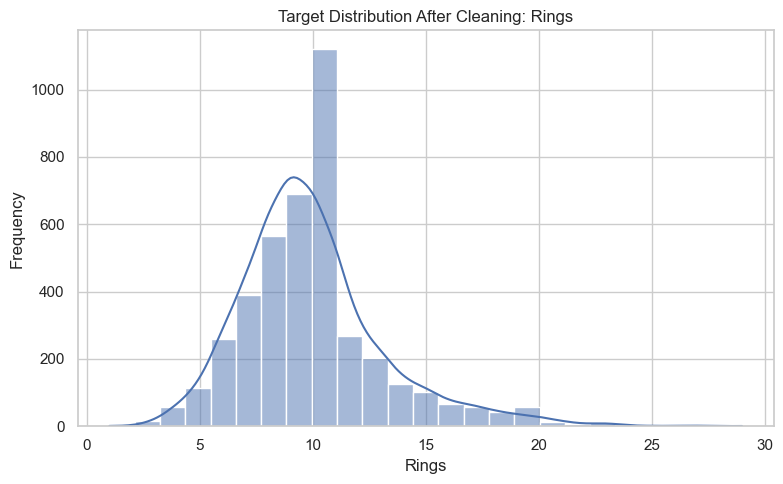

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Rings"], bins=25, kde=True)
plt.title("Target Distribution After Cleaning: Rings")
plt.xlabel("Rings")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

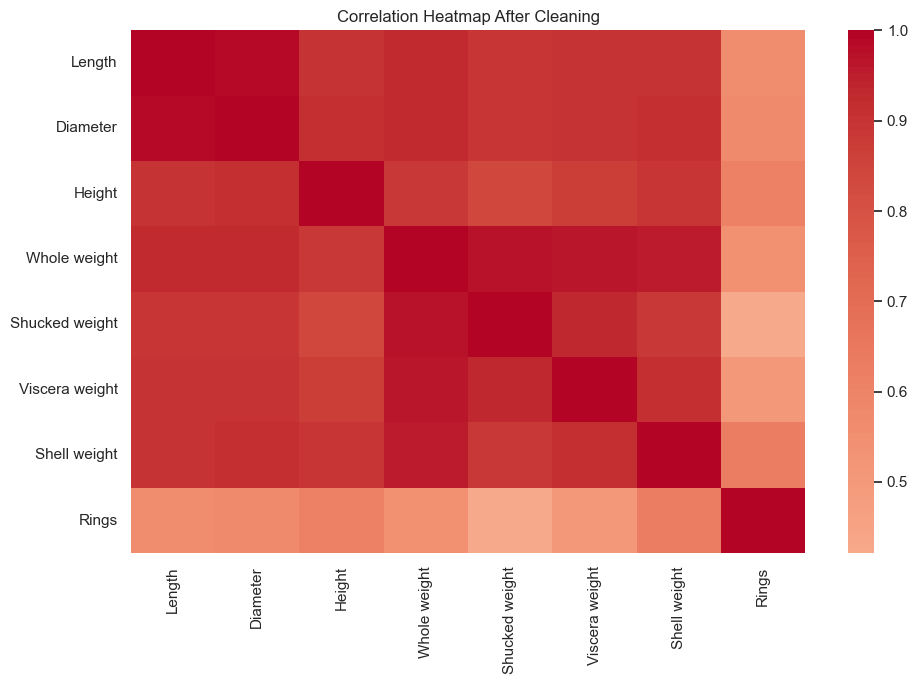

In [33]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[df.select_dtypes(include=["int64", "float64"]).columns].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap After Cleaning")
plt.tight_layout()
plt.show()

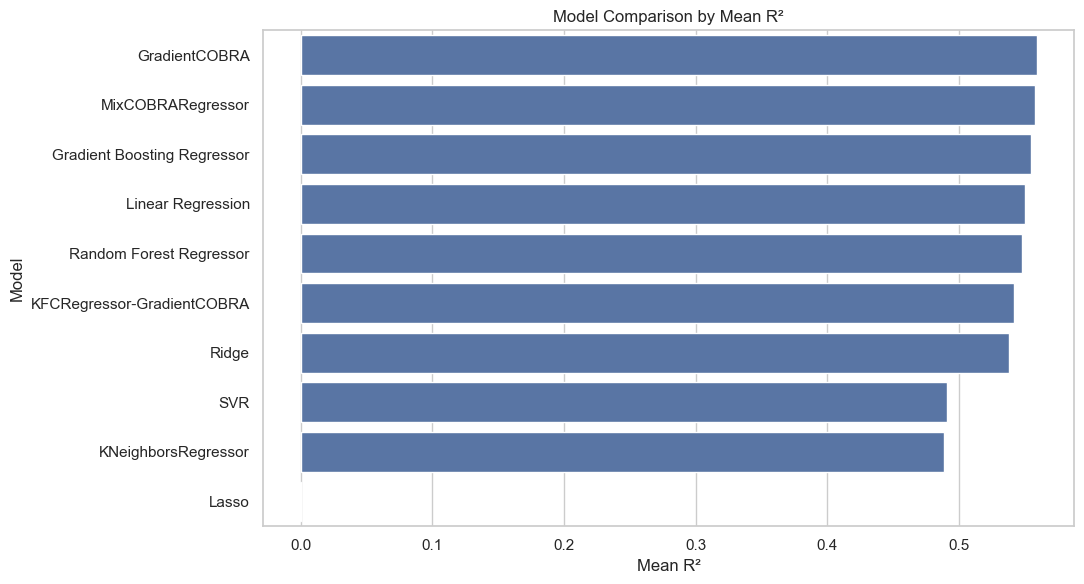

In [34]:
comparison_plot_data = aggregated_results_table.reset_index()

plt.figure(figsize=(11, 6))
sns.barplot(
    data=comparison_plot_data,
    x=("R2", "mean"),
    y=("Model", ""),
    orient="h",
)
plt.title("Model Comparison by Mean R²")
plt.xlabel("Mean R²")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

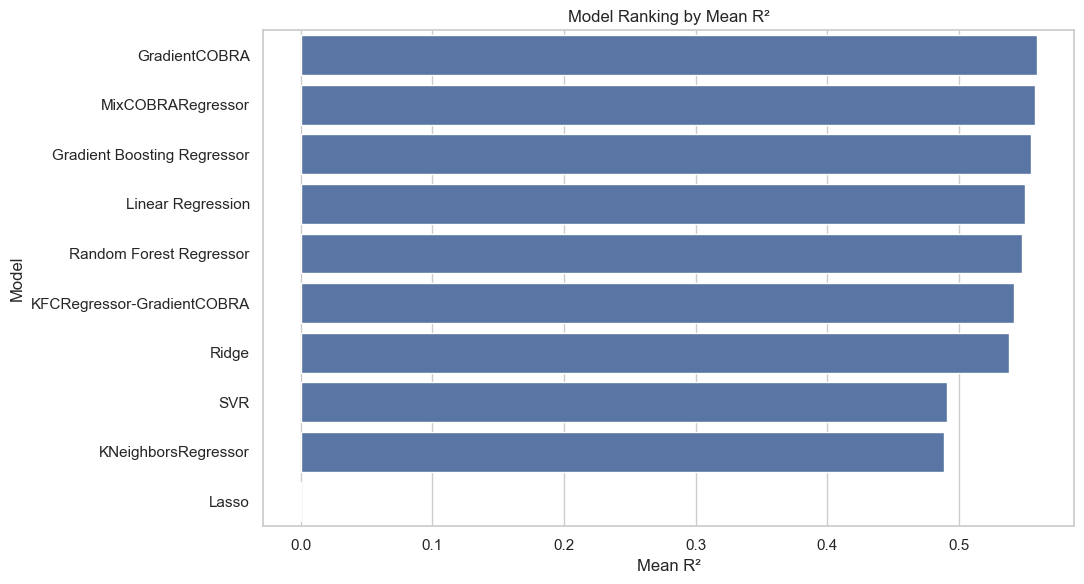

In [35]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=ranking_table,
    x=f"Mean {PRIMARY_METRIC}",
    y="Model",
    orient="h",
)
plt.title("Model Ranking by Mean R²")
plt.xlabel("Mean R²")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

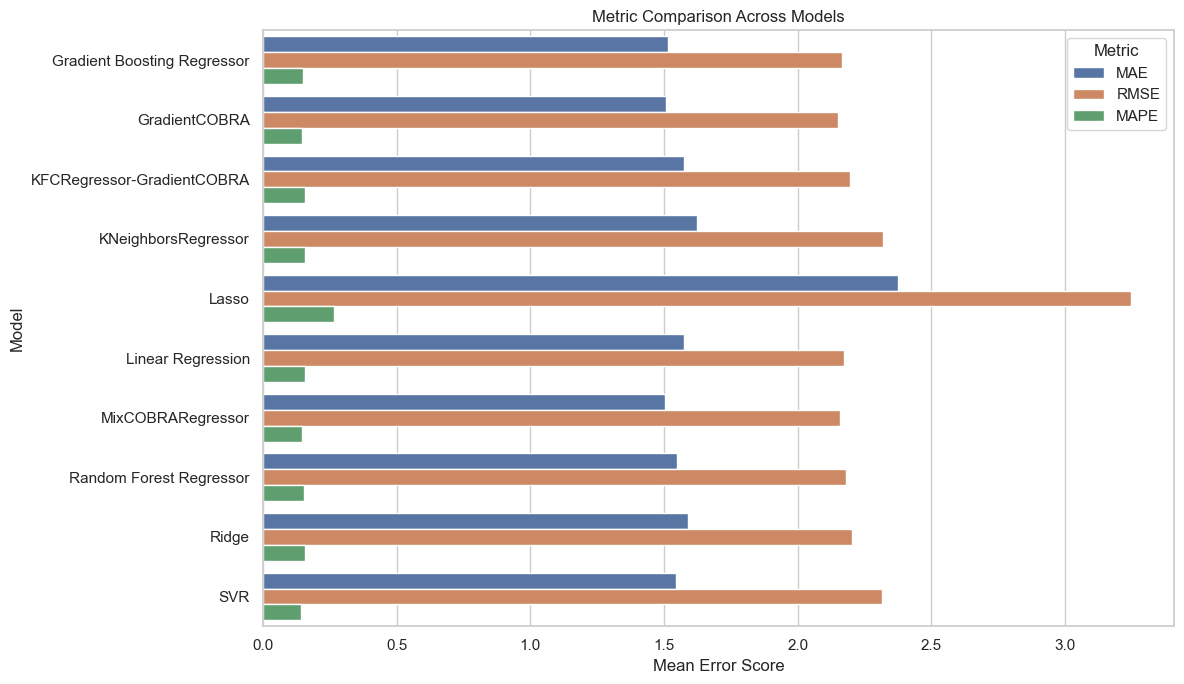

In [36]:
metric_comparison_data = (
    per_seed_results_table
    .groupby("Model")[["MAE", "RMSE", "MAPE"]]
    .mean()
    .reset_index()
)

metric_comparison_long = metric_comparison_data.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE", "MAPE"],
    var_name="Metric",
    value_name="Mean Score",
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=metric_comparison_long,
    x="Mean Score",
    y="Model",
    hue="Metric",
    orient="h",
)
plt.title("Metric Comparison Across Models")
plt.xlabel("Mean Error Score")
plt.ylabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 18. LaTeX-Ready Tables

The following cells generate LaTeX-ready tables from computed results. No values are manually inserted.

In [37]:
latex_per_seed_table = per_seed_results_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Per-seed Abalone regression results.",
    label="tab:abalone_per_seed_results",
)

print(latex_per_seed_table)

\begin{table}
\caption{Per-seed Abalone regression results.}
\label{tab:abalone_per_seed_results}
\begin{tabular}{lrrrrrrrrr}
\toprule
Model & Seed & MAE & MSE & RMSE & R2 & MAPE & AVG_Y_TRUE & Fit Time & Prediction Time \\
\midrule
Gradient Boosting Regressor & 42 & 1.5361 & 4.9362 & 2.2218 & 0.5881 & 0.1455 & 10.0192 & 0.2441 & 0.0007 \\
GradientCOBRA & 42 & 1.5254 & 4.8624 & 2.2051 & 0.5942 & 0.1455 & 10.0192 & 14.8374 & 1.5812 \\
KFCRegressor-GradientCOBRA & 42 & 1.5988 & 5.1148 & 2.2616 & 0.5732 & 0.1571 & 10.0192 & 3.8946 & 0.0211 \\
KNeighborsRegressor & 42 & 1.6113 & 5.6271 & 2.3721 & 0.5304 & 0.1502 & 10.0192 & 0.0007 & 0.0030 \\
Lasso & 42 & 2.5412 & 11.9938 & 3.4632 & -0.0009 & 0.2833 & 10.0192 & 0.0003 & 0.0001 \\
Linear Regression & 42 & 1.5841 & 4.9693 & 2.2292 & 0.5853 & 0.1556 & 10.0192 & 0.0006 & 0.0000 \\
MixCOBRARegressor & 42 & 1.5266 & 4.9114 & 2.2162 & 0.5901 & 0.1451 & 10.0192 & 20.7227 & 0.0673 \\
Random Forest Regressor & 42 & 1.5494 & 4.9945 & 2.2348 & 0.5832 

In [38]:
latex_aggregated_table = formatted_aggregated_results.to_latex(
    index=False,
    escape=False,
    caption="Aggregated Abalone regression results across five random seeds.",
    label="tab:abalone_aggregated_results",
)

print(latex_aggregated_table)

\begin{table}
\caption{Aggregated Abalone regression results across five random seeds.}
\label{tab:abalone_aggregated_results}
\begin{tabular}{lllllll}
\toprule
Model & MAE & MSE & RMSE & R2 & MAPE & AVG_Y_TRUE \\
\midrule
GradientCOBRA & 1.508 ± 0.041 & 4.636 ± 0.325 & 2.152 ± 0.076 & 0.559 ± 0.024 & 0.148 ± 0.004 & 9.971 ± 0.052 \\
MixCOBRARegressor & 1.504 ± 0.040 & 4.655 ± 0.301 & 2.157 ± 0.070 & 0.557 ± 0.020 & 0.147 ± 0.004 & 9.971 ± 0.052 \\
Gradient Boosting Regressor & 1.515 ± 0.033 & 4.685 ± 0.268 & 2.164 ± 0.062 & 0.554 ± 0.021 & 0.149 ± 0.004 & 9.971 ± 0.052 \\
Linear Regression & 1.574 ± 0.020 & 4.730 ± 0.226 & 2.174 ± 0.052 & 0.550 ± 0.023 & 0.157 ± 0.003 & 9.971 ± 0.052 \\
Random Forest Regressor & 1.547 ± 0.031 & 4.754 ± 0.262 & 2.180 ± 0.060 & 0.548 ± 0.022 & 0.153 ± 0.005 & 9.971 ± 0.052 \\
KFCRegressor-GradientCOBRA & 1.573 ± 0.030 & 4.820 ± 0.261 & 2.195 ± 0.060 & 0.541 ± 0.022 & 0.158 ± 0.002 & 9.971 ± 0.052 \\
Ridge & 1.588 ± 0.027 & 4.857 ± 0.247 & 2.203 ± 0.057 

In [39]:
latex_ranking_table = ranking_table.to_latex(
    index=False,
    float_format="%.4f",
    caption="Model ranking by mean R2 for the Abalone regression experiment.",
    label="tab:abalone_model_ranking",
)

print(latex_ranking_table)

\begin{table}
\caption{Model ranking by mean R2 for the Abalone regression experiment.}
\label{tab:abalone_model_ranking}
\begin{tabular}{rlr}
\toprule
Rank & Model & Mean R2 \\
\midrule
1 & GradientCOBRA & 0.5593 \\
2 & MixCOBRARegressor & 0.5574 \\
3 & Gradient Boosting Regressor & 0.5545 \\
4 & Linear Regression & 0.5498 \\
5 & Random Forest Regressor & 0.5478 \\
6 & KFCRegressor-GradientCOBRA & 0.5415 \\
7 & Ridge & 0.5379 \\
8 & SVR & 0.4907 \\
9 & KNeighborsRegressor & 0.4889 \\
10 & Lasso & -0.0005 \\
\bottomrule
\end{tabular}
\end{table}



## 19. Discussion

### Comparison of Baselines

The baseline models establish the reference performance for the Abalone regression task. The comparison should be based on the aggregated mean and standard deviation table rather than a single train-test split.

### Comparison of COBRA Models

The COBRA regression models evaluated in this notebook are `GradientCOBRA` and `MixCOBRARegressor`. These are appropriate for the regression setting and are supported by the repository notebook.

`CombinedClassifier` is not evaluated because it is a classification model and is not appropriate for the Abalone regression task.

### Comparison of KFC Models

The KFCProcedure models use divergence-based clustering in the K-Step, cluster-wise linear regression in the F-Step, and COBRA-style regression aggregation in the C-Step.

The two KFC variants differ only in the C-Step combiner:

- `KFCRegressor-GradientCOBRA`
- `KFCRegressor-MixCOBRA`

### Strengths

The experiment has the following strengths:

1. It uses repeated evaluation across five random seeds.
2. All models are evaluated on the same seed-specific train-test splits.
3. Preprocessing is fitted only on the training split, preventing data leakage.
4. The same evaluation metrics are used for all models.
5. Results are reported using mean and standard deviation.
6. KFCProcedure models are configured using repository-supported divergences, local models, and combiners.

### Limitations

The experiment has the following limitations:

1. Hyperparameter tuning beyond the repository-supported configuration is not introduced.
2. The KFCProcedure models may be computationally expensive because they combine clustering, local modeling, and COBRA aggregation.
3. The experiment uses repeated holdout evaluation rather than nested cross-validation.
4. Only the `Height` filtering rule observable in the repository notebook is applied; broader outlier handling is not defined.
5. Feature selection is not applied because it is not observable from the provided materials.

### Threats to Validity

Potential threats to validity include:

1. Results may vary under different hyperparameter choices.
2. Runtime can vary depending on hardware and package versions.
3. The Abalone dataset may not represent all biological age-prediction settings.
4. Model ranking may change under alternative validation protocols.
5. Complex aggregation models may be less interpretable than simpler baseline regressors.

In [40]:
baseline_model_names = [
    "Linear Regression",
    "Ridge",
    "Lasso",
    "Random Forest Regressor",
    "Gradient Boosting Regressor",
    "SVR",
    "KNeighborsRegressor",
]

baseline_ranking = ranking_table[
    ranking_table["Model"].isin(baseline_model_names)
].reset_index(drop=True)

cobra_ranking = ranking_table[
    ranking_table["Model"].isin(["GradientCOBRA", "MixCOBRARegressor"])
].reset_index(drop=True)

kfc_ranking = ranking_table[
    ranking_table["Model"].str.startswith("KFCRegressor")
].reset_index(drop=True)

print("Baseline ranking:")
display(baseline_ranking)

print("COBRA ranking:")
display(cobra_ranking)

print("KFCProcedure ranking:")
display(kfc_ranking)

Baseline ranking:


,Rank,Model,Mean R2
0,3,Gradient Boosting Regressor,0.554460
1,4,Linear Regression,0.549840
2,5,Random Forest Regressor,0.547781
3,7,Ridge,0.537871
4,8,SVR,0.490681
5,9,KNeighborsRegressor,0.488852
6,10,Lasso,-0.000493


COBRA ranking:


,Rank,Model,Mean R2
0,1,GradientCOBRA,0.559268
1,2,MixCOBRARegressor,0.557425


KFCProcedure ranking:


,Rank,Model,Mean R2
0,6,KFCRegressor-GradientCOBRA,0.541491


## 20. Conclusion

This notebook implemented a complete Abalone regression experiment for the thesis project:

**kfc-procedure: A Unified Framework for Clusterwise Learning and COBRA-Based Ensemble Aggregation**

The experiment evaluated:

1. Baseline regression models
2. Repository-supported COBRA regression models
3. KFCProcedure regression models

The methodology used five repeated train-test splits with the seeds:

```python
[42, 52, 62, 72, 82]
```

For every seed, the dataset was split, preprocessed, trained, predicted, and evaluated independently. The final result tables report mean and standard deviation for regression metrics.

No performance claim should be made without referring to the computed per-seed and aggregated result tables generated by this notebook.

## 21. Reproducibility Checklist

The following reproducibility controls are applied:

- Dataset source is explicitly stated.
- Target variable is explicitly defined.
- Feature preprocessing is performed inside each train-test split.
- Numerical imputation and scaling are fitted only on training data.
- Categorical imputation and one-hot encoding are fitted only on training data.
- Random seeds are fixed and reported.
- All models use the same train-test split for each seed.
- All metrics are computed consistently.
- Per-seed results are stored in `all_results`.
- Aggregated mean and standard deviation are computed from per-seed results.
- LaTeX-ready tables are generated from computed results.
- `CombinedClassifier` is explicitly excluded from model evaluation because it is classification-only and this experiment is regression.